# CBIS-DDSM MedSigLIP embeddings

This notebook demonstrates how to use the clean CBIS-DDSM dataset with MedSigLIP. It reads `labels.csv`, selects example mammography images from the dataset, extracts image and text embeddings, compares them with simple prompts related to benign/malignant findings and abnormality type, and visualizes the embeddings with PCA.

----

Este notebook muestra cómo usar el dataset CBIS-DDSM con MedSigLIP. Lee `labels.csv`, selecciona ejemplos de mamografías desde el dataset, extrae embeddings de imagen y texto, los compara con prompts simples relacionados con hallazgos benignos/malignos y tipo de anormalidad, y visualiza los embeddings con PCA.


In [1]:
from pathlib import Path
import os

from dotenv import load_dotenv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.decomposition import PCA
import torch
from transformers import AutoModel, AutoProcessor

load_dotenv()
HF_TOKEN = os.getenv("HF_TOKEN")
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

MODEL_ID = "google/medsiglip-448"
processor = AutoProcessor.from_pretrained(MODEL_ID, token=HF_TOKEN)
model = AutoModel.from_pretrained(MODEL_ID, token=HF_TOKEN).to(device)
model.eval()


device: cpu


The image processor of type `SiglipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loading weights:   0%|          | 0/888 [00:00<?, ?it/s]

SiglipModel(
  (text_model): SiglipTextTransformer(
    (embeddings): SiglipTextEmbeddings(
      (token_embedding): Embedding(32000, 1152)
      (position_embedding): Embedding(64, 1152)
    )
    (encoder): SiglipEncoder(
      (layers): ModuleList(
        (0-26): 27 x SiglipEncoderLayer(
          (layer_norm1): LayerNorm((1152,), eps=1e-06, elementwise_affine=True)
          (self_attn): SiglipAttention(
            (k_proj): Linear(in_features=1152, out_features=1152, bias=True)
            (v_proj): Linear(in_features=1152, out_features=1152, bias=True)
            (q_proj): Linear(in_features=1152, out_features=1152, bias=True)
            (out_proj): Linear(in_features=1152, out_features=1152, bias=True)
          )
          (layer_norm2): LayerNorm((1152,), eps=1e-06, elementwise_affine=True)
          (mlp): SiglipMLP(
            (activation_fn): GELUTanh()
            (fc1): Linear(in_features=1152, out_features=4304, bias=True)
            (fc2): Linear(in_features=4304,

In [2]:
# Reemplazar con tu ruta al dataset
# DATASET_DIR = Path("PATH-TO-DATASET/CBIS-DDSM-clean")
DATASET_DIR = Path(os.environ["SCRATCH"]) / "datasets" / "datatondatasets" / "CBIS-DDSM-clean"

labels = pd.read_csv(DATASET_DIR / "labels.csv")
print(labels.shape)
labels.head()


(3568, 19)


,image,split,patient_id,left_or_right_breast,image_view,abnormality_id,abnormality_type,assessment,breast_density,pathology,is_malignant,subtlety,mass_shape,mass_margins,calc_type,calc_distribution,source_case_csv,source_image_file_path,source_series_instance_uid
0,train_mass_P_00001_LEFT_CC_1_1.png,train,P_00001,LEFT,CC,1,mass,4,3,MALIGNANT,1,4,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,NaN,NaN,mass_train.csv,Mass-Training_P_00001_LEFT_CC/1.3.6.1.4.1.9590...,1.3.6.1.4.1.9590.100.1.2.342386194811267636608...
1,train_mass_P_00001_LEFT_MLO_1_2.png,train,P_00001,LEFT,MLO,1,mass,4,3,MALIGNANT,1,4,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,NaN,NaN,mass_train.csv,Mass-Training_P_00001_LEFT_MLO/1.3.6.1.4.1.959...,1.3.6.1.4.1.9590.100.1.2.359308329312397897125...
2,train_mass_P_00004_LEFT_CC_1_3.png,train,P_00004,LEFT,CC,1,mass,4,3,BENIGN,0,3,ARCHITECTURAL_DISTORTION,ILL_DEFINED,NaN,NaN,mass_train.csv,Mass-Training_P_00004_LEFT_CC/1.3.6.1.4.1.9590...,1.3.6.1.4.1.9590.100.1.2.891800462110225318343...
3,train_mass_P_00004_LEFT_MLO_1_4.png,train,P_00004,LEFT,MLO,1,mass,4,3,BENIGN,0,3,ARCHITECTURAL_DISTORTION,ILL_DEFINED,NaN,NaN,mass_train.csv,Mass-Training_P_00004_LEFT_MLO/1.3.6.1.4.1.959...,1.3.6.1.4.1.9590.100.1.2.295360926313492745441...
4,train_mass_P_00004_RIGHT_MLO_1_5.png,train,P_00004,RIGHT,MLO,1,mass,4,3,BENIGN,0,5,OVAL,CIRCUMSCRIBED,NaN,NaN,mass_train.csv,Mass-Training_P_00004_RIGHT_MLO/1.3.6.1.4.1.95...,1.3.6.1.4.1.9590.100.1.2.410524754913057908920...


In [3]:
def load_rgb(path):
    return Image.open(path).convert("RGB")


def run_medsiglip(images, texts):
    inputs = processor(
        text=texts,
        images=images,
        padding="max_length",
        return_tensors="pt",
    ).to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    probs = torch.softmax(outputs.logits_per_image, dim=1).detach().cpu().numpy()
    image_embeds = outputs.image_embeds.detach().cpu().numpy()
    text_embeds = outputs.text_embeds.detach().cpu().numpy()
    return probs, image_embeds, text_embeds


def show_predictions(images, texts, probs):
    for image_index, image in enumerate(images):
        display(image)
        for text, score in zip(texts, probs[image_index]):
            print(f"{score:.2%} - {text}")
        print()


def plot_embedding_pca(image_embeds, text_embeds, image_labels, text_labels, title):
    vectors = np.vstack([image_embeds, text_embeds])
    coords = PCA(n_components=2, random_state=0).fit_transform(vectors)
    n_images = len(image_embeds)

    plt.figure(figsize=(7, 5))
    plt.scatter(coords[:n_images, 0], coords[:n_images, 1], label="images", s=90)
    plt.scatter(coords[n_images:, 0], coords[n_images:, 1], label="texts", marker="x", s=90)

    for label, (x, y) in zip(image_labels, coords[:n_images]):
        plt.text(x, y, label, fontsize=9)
    for label, (x, y) in zip(text_labels, coords[n_images:]):
        plt.text(x, y, label, fontsize=9)

    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [4]:
sample = labels.sample(min(2, len(labels)), random_state=5).reset_index(drop=True)
images = [load_rgb(DATASET_DIR / "images" / row.image) for row in sample.itertuples()]
image_labels = [f"image {i}" for i in range(len(images))]

texts = [
    "a benign mammogram",
    "a malignant mammogram",
    "a mammogram with a mass",
    "a mammogram with calcification",
]

sample[["image", "pathology", "is_malignant", "abnormality_type", "assessment"]].head()


,image,pathology,is_malignant,abnormality_type,assessment
0,train_calcification_P_00019_RIGHT_CC_1_1729.png,BENIGN,0,calcification,4
1,train_calcification_P_00854_RIGHT_CC_1_2372.png,BENIGN,0,calcification,4


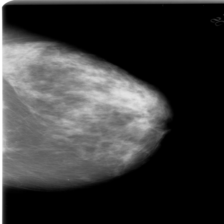

27.47% - a benign mammogram
23.28% - a malignant mammogram
23.34% - a mammogram with a mass
25.92% - a mammogram with calcification



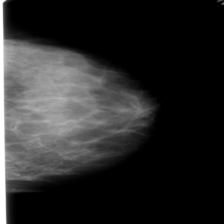

28.44% - a benign mammogram
22.54% - a malignant mammogram
22.86% - a mammogram with a mass
26.15% - a mammogram with calcification

image embeddings: (2, 1152)
text embeddings: (4, 1152)


In [5]:
probs, image_embeds, text_embeds = run_medsiglip(images, texts)
show_predictions(images, texts, probs)
print("image embeddings:", image_embeds.shape)
print("text embeddings:", text_embeds.shape)


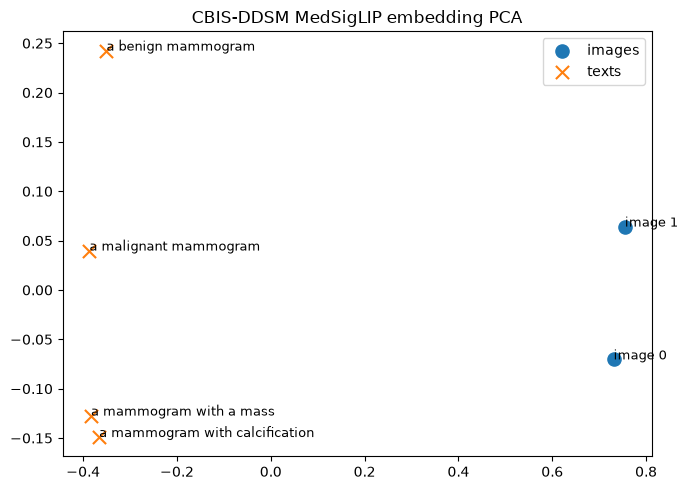

In [6]:
plot_embedding_pca(
    image_embeds,
    text_embeds,
    image_labels=image_labels,
    text_labels=texts,
    title="CBIS-DDSM MedSigLIP embedding PCA",
)
